In [42]:
from matplotlib import pyplot as plt
import numpy as np

import wandb

import pandas as pd

In [39]:
api = wandb.Api()

In [40]:
PROJECT = "p16i/xaikd-s51-distillation-some-vs-others"
EXPERIMENT_GROUP= "distillation--some-vs-others-with-optimal-lambda"

In [119]:
def read_data_per_policy(
    teacher, student,
    dataset,
    policy_alias,

    verbose=False,
    return_raw = False,
    training_size=1.0,
    experiment_group=EXPERIMENT_GROUP
):
    
    if policy_alias == "kd-only":
        lambda_task = 0
        lambda_kd = 1
        policy = "nothing"
    elif policy_alias == "student-only":
        lambda_task = 1
        lambda_kd = 0
        policy = "nothing"
    else:
        lambda_task = 0
        lambda_kd = 1
        policy = policy_alias
            
    runs = api.runs(
        PROJECT,
        {
        "$and": [
            {"group": experiment_group},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.dataset": dataset},
            {"config.lambda-task": lambda_task},
            {"config.lambda-kd": lambda_kd},
            {"config.training_size": training_size},
            {"config.policy": policy},
        ]}
    )
    
    if verbose:
        print(f"{policy_alias} we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        if not "arr_metrics"in run.summary:
            print(f">> bad run config (id={run.id}")

            count += 1
            return run
            continue

        rows.append(
            dict(
                policy_alias=policy_alias,
                val_auroc=run.summary["arr_metrics"]["val_auroc"][-1], 
                train_auroc=run.summary["arr_metrics"]["train_auroc"][-1],
                # fixme: currently, there is a bug in the code where we use teacher_acc as teacher_auroc
                teacher_auroc=run.summary["teacher_auroc"],
                run_id=run.id,
                **run.config
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    assert df.shape[0] > 0
    df = df.groupby(by="policy_alias").agg(
        {
            "val_auroc": ["mean", "sem", "count"],
            "train_auroc": ["mean", "sem", "count"],

            "teacher_auroc": ["mean"],
            "policy": ["first"],
            "lambda_task": ["first"],
            "lambda_kd": ["first"],
            "lambda_layer": ["first"],
        }
    ).reset_index()
    
    np.testing.assert_allclose(
        df["val_auroc"]["count"].values,
        3
    )
    
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

read_data_per_policy(
    teacher="cifar100-resnet18-v1",
    student="student-mobilenetxs",
    
    dataset = "cifar100-people-vs-others",
    policy_alias="kd-only",
    training_size=0.125,
    verbose=True,
)

kd-only we have 3 runs
df.shape: (1, 12)


policy_alias val_auroc                train_auroc                 \
                    mean      sem count        mean      sem count   
0      kd-only  0.860776  0.00938     3    0.899173  0.00096     3   

  teacher_auroc   policy lambda_task lambda_kd lambda_layer  
           mean    first       first     first        first  
0      0.994983  nothing           0         1            0

In [117]:
def read_data(arr_policies, **kwargs):
    arr_dfs = []

    for policy in arr_policies:
        arr_dfs.append(
            read_data_per_policy(
                policy_alias=policy,
                **kwargs,
            )
        )
    return pd.concat(arr_dfs)

read_data(
    teacher="cifar100-resnet18-v1",
    student="student-mobilenetxs",
    
    dataset = "cifar100-people-vs-others",
    arr_policies=[
        "kd-only",
        "vid"
    ],
    training_size=0.125,
    verbose=True,
)

policy: nothing
kd-only we have 3 runs
df.shape: (1, 12)
policy: vid
vid we have 3 runs
df.shape: (1, 12)


policy_alias val_auroc                 train_auroc                  \
                    mean       sem count        mean       sem count   
0      kd-only  0.860776  0.009380     3    0.899173  0.000960     3   
0          vid  0.881693  0.007984     3    0.891086  0.016009     3   

  teacher_auroc   policy lambda_task lambda_kd lambda_layer  
           mean    first       first     first        first  
0      0.994983  nothing           0         1            0  
0      0.994984      vid           0         1           10

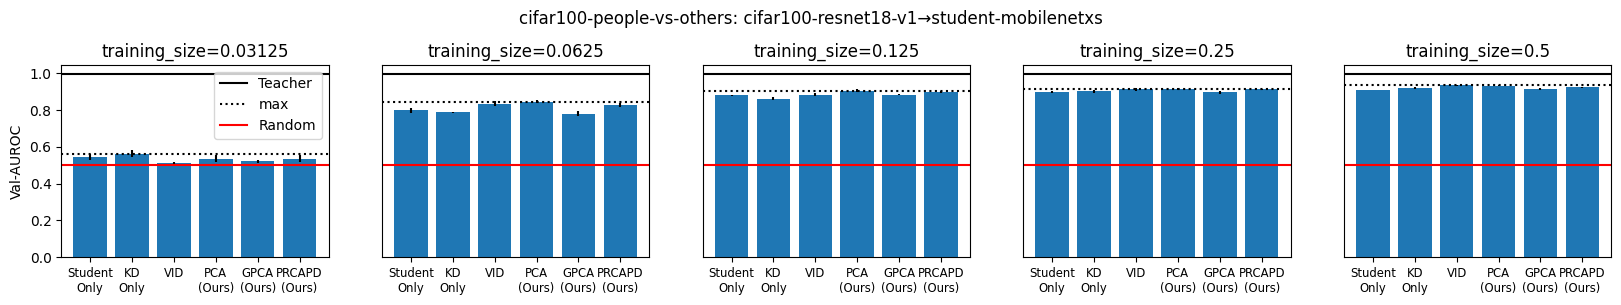

In [132]:
def _alias_policy(name):
    return {
        "student-only": "Student\nOnly",
        "kd-only": "KD\nOnly",
        "vid": "VID",
        "basis-bn:pca": "PCA\n(Ours)",
        "basis-bn:gradpca": "GPCA\n(Ours)",
        "basis-bn:prcaposdef": "PRCAPD\n(Ours)",
    }[name]

def viz(
    dataset_name,
    teacher, student, 
    arr_training_sizes=[
        0.03125,
        0.0625,
        0.125, 
        0.25, 
        0.5
    ],
    arr_policies=[
        "student-only",
        "kd-only",
        "vid",
        "basis-bn:pca",
        "basis-bn:gradpca",
        "basis-bn:prcaposdef",
    ]
):
    
    nrows = 1
    ncols = len(arr_training_sizes)
    
    plt.figure(figsize=(4*ncols, 2.5 * nrows))
    
    plt.suptitle(f"{dataset_name}: {teacher}→{student}", y=1.1)
    
    xticks = np.arange(len(arr_policies))
    for tix, training_size in enumerate(arr_training_sizes):
        plt.subplot(1, ncols, tix +1)

        plt.title(f"training_size={training_size}")
        
        
        
        df=read_data(
            teacher=teacher,
            student=student,
            dataset=dataset_name,
            arr_policies=arr_policies,
            training_size=training_size,
        )
        
        assert df.shape[0] == len(arr_policies)
        
        arr_means = np.zeros(df.shape[0])
        arr_sems = np.zeros(df.shape[0])
        for pix, policy in enumerate(arr_policies):
            _df = df[df.policy_alias == policy]
            assert _df.shape[0] == 1
            assert (_df["val_auroc"]["count"].values == 3).all()
            value = _df["val_auroc"]["mean"].values[0]
            arr_means[pix] = value
            arr_sems[pix] = _df["val_auroc"]["sem"].values[0]
            
        
        teacher_value = df.teacher_auroc["mean"].values[-1]
        
        plt.axhline(teacher_value, ls="-", color="k", label="Teacher")
        
        plt.bar(
            xticks,
            arr_means,
            yerr=arr_sems
        )
    
        
        plt.axhline(np.max(arr_means), ls=":", color="k", label="max")
        plt.axhline(0.5, color="r", ls="-", label="Random")
        if tix == 0:
            plt.ylabel("Val-AUROC")
            plt.legend()
        else:
            plt.yticks([])
        plt.xticks(
            xticks, 
            list(map(lambda n: _alias_policy(n), arr_policies)),
            fontsize="small"
        )
        
viz(
    dataset_name="cifar100-people-vs-others",
    teacher="cifar100-resnet18-v1",
    student="student-mobilenetxs"
)

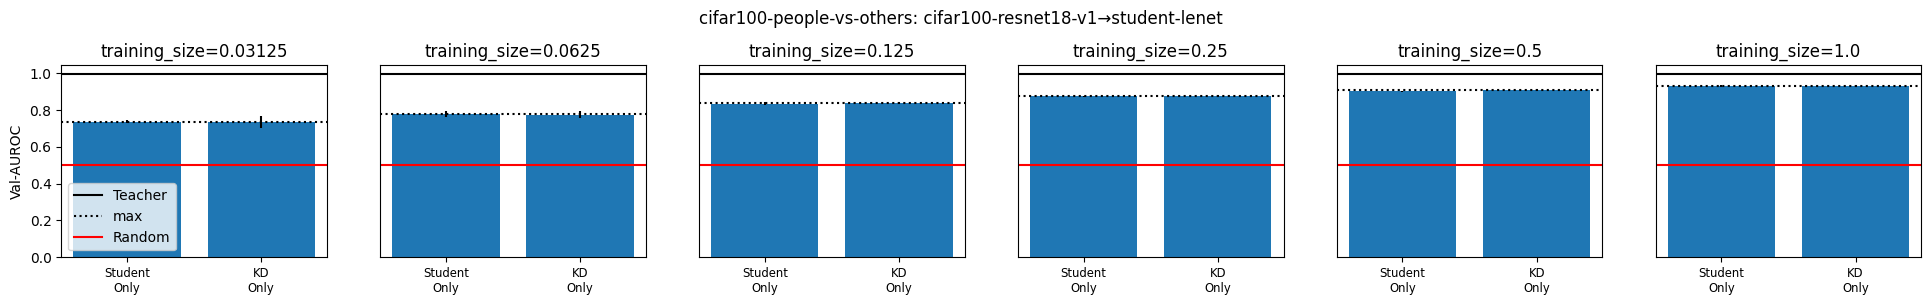

In [133]:
viz(
    dataset_name="cifar100-people-vs-others",
    teacher="cifar100-resnet18-v1",
    student="student-lenet",
    arr_policies=["student-only", "kd-only"],
    arr_training_sizes=[
        0.03125,
        0.0625,
        0.125, 
        0.25, 
        0.5,
        1.0
    ],
)